# 🚀 Backtest Vectorisé : Stratégie Regime-Switching Momentum
Ce notebook contient **absolument tout le code source** (fonctions, classe, imports) pour que tu puisses le modifier et l'exécuter d'une traite sans dépendre de fichiers externes.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import yfinance as yf
import ta
import warnings
from datetime import datetime
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# 1. SETUP DE L'ENVIRONNEMENT & SPARK
# ==========================================
# Fix random seeds for reproducibility
np.random.seed(42)

# Remonter à la racine du projet de manière robuste (Ton code)
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())
load_dotenv()

try:
    from src.common.setup_spark import create_spark_session
    from config.config_spark import Paths
    print("✅ Imports locaux réussis !")
except Exception as e:
    print(f"❌ Erreur d'importation locale : {e}")
    sys.exit(1)

print("🚀 Initialisation de la Spark Session...")
spark = create_spark_session("Regime_Switching_Backtest")
print("✅ Spark Session créée avec succès.")


2026-03-28 15:34:48.564 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


✅ Imports locaux réussis !
🚀 Initialisation de la Spark Session...


26/03/28 15:34:49 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/28 15:34:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-108cbba9-f595-4cfe-9036-777e13185ead;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central


:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 75ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   0   ||   3   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark#spark-submit-parent-108cbba9-f595-4cfe-9036-777e13185ead
	confs: [default]
	0 artifacts copied, 3 already retrieved (0kB/3ms)
26/03/28 15:34:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-ja

✅ Spark Session créée avec succès.


In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import ta
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

class RegimeSwitchingMomentumBacktester:
    def __init__(self, start_date="2010-01-01", end_date=None):
        self.start_date = start_date
        self.end_date = end_date or datetime.today().strftime('%Y-%m-%d')
        
        self.etf_tickers = [
            'XLP', 'XLV', 'XLU', 'XLE', 'XLK', 'XLC', 'XLI', 'XLY', 
            'XLB', 'XLRE', 'TLT', 'IEF', 'HYG', 'GLD', 'VNQ'
        ]
        
    def get_sp500_regime(self) -> pd.DataFrame:
        print("📈 Fetching S&P 500 data for Regime Filter...")
        sp500 = yf.download('^GSPC', start=self.start_date, end=self.end_date, progress=False)
        sp500 = pd.DataFrame(sp500['Close'].resample('W-FRI').last())
        sp500.columns = ['Close']
        sp500['SMA_12'] = ta.trend.sma_indicator(sp500['Close'], window=26)
        sp500['SMA_26'] = ta.trend.sma_indicator(sp500['Close'], window=70)
        
        cond_bull = (sp500['SMA_12'] > sp500['SMA_26']) & (sp500['Close'] > sp500['SMA_26']) | (sp500['SMA_12'] < sp500['SMA_26']) & (sp500['Close'] > sp500['SMA_12'])
        sp500['Regime'] = np.where(cond_bull, 'Bull', 'Bear')
        
        sp500.index = pd.to_datetime(sp500.index).tz_localize(None).normalize()
        return sp500[['Close', 'SMA_12', 'SMA_26', 'Regime']]
        
    def get_etf_data(self) -> pd.DataFrame:
        print("🛡️ Fetching ETF data...")
        etf_data = yf.download(self.etf_tickers, start=self.start_date, end=self.end_date, progress=False)
        etf_close = etf_data['Close'].resample('W-FRI').last()
        
        df_list = []
        for ticker in self.etf_tickers:
            df = etf_close[[ticker]].dropna().rename(columns={ticker: 'Close'})
            df['Ticker'] = ticker
            
            df['SMA_12'] = ta.trend.sma_indicator(df['Close'], window=12)
            df['SMA_26'] = ta.trend.sma_indicator(df['Close'], window=26)
            df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
            df['Momentum_3M'] = df['Close'].pct_change(periods=13)
            
            df['Eligible'] = (df['SMA_12'] > df['SMA_26']) & (df['Close'] > df['SMA_26'])
            df_list.append(df.reset_index())
            
        res = pd.concat(df_list, ignore_index=True)
        res = res.rename(columns={'Date': 'date'})
        res['date'] = pd.to_datetime(res['date']).dt.tz_localize(None).dt.normalize()
        return res

    def load_and_prep_stock_data(self, spark_session) -> pd.DataFrame:
        print(f"📡 Loading Daily S&P 500 Constituent Data from: {Paths.SP500_STOCK_PRICES}")
        df_bronze = spark_session.read.format("delta").load(Paths.SP500_STOCK_PRICES)
        pd_df = df_bronze.select('date', 'symbol', 'adjHigh', 'adjLow', 'adjClose').toPandas()
        
        pd_df['date'] = pd.to_datetime(pd_df['date']).dt.tz_localize(None).dt.normalize()
        print(f"Loaded {len(pd_df)} daily price records. Processing indicators and resampling to weekly...")

        results = []
        for symbol, df in pd_df.groupby('symbol'):
            df = df.sort_values('date').set_index('date')
            if len(df) < 130:
                continue
            
            df['ADX_20'] = ta.trend.adx(df['adjHigh'], df['adjLow'], df['adjClose'], window=20, fillna=True)
            df['ATR_14'] = ta.volatility.average_true_range(df['adjHigh'], df['adjLow'], df['adjClose'], window=14, fillna=True)
            
            weekly_df = df.resample('W-FRI').agg({
                'adjClose': 'last', 'ADX_20': 'last', 'ATR_14': 'last'
            }).dropna(subset=['adjClose'])
            
            weekly_df['SMA_12'] = ta.trend.sma_indicator(weekly_df['adjClose'], window=12)
            weekly_df['SMA_26'] = ta.trend.sma_indicator(weekly_df['adjClose'], window=26)
            weekly_df['SMA_55'] = ta.trend.sma_indicator(weekly_df['adjClose'], window=55)
            
            # 👇 LIGNE À MODIFIER POUR TES TESTS DE MOYENNE MOBILE
            weekly_df['SMA_STOP'] = ta.trend.sma_indicator(weekly_df['adjClose'], window=70) 
            
            weekly_df['ATR_pct'] = weekly_df['ATR_14'] / weekly_df['adjClose']
            weekly_df['Momentum_6M'] = weekly_df['adjClose'].pct_change(periods=26)
            weekly_df['Momentum_3M'] = weekly_df['adjClose'].pct_change(periods=13)
            weekly_df['Momentum_1W'] = weekly_df['adjClose'].pct_change(periods=1)
            
            # Attention : Ton filtre d'achat initial exigeait que le prix soit au-dessus de SMA_26
            cond_trend = (weekly_df['SMA_26'] < weekly_df['SMA_55']) & (weekly_df['adjClose'] < weekly_df['SMA_26'])
            cond_strength = weekly_df['ADX_20'] > 0
            cond_volatility = weekly_df['ATR_pct'] < 1
            cond_1W = weekly_df['Momentum_1W'] < 0.0           
            
            weekly_df['Eligible'] = cond_trend
            weekly_df['Ticker'] = symbol
            results.append(weekly_df.reset_index())

        if not results:
            return pd.DataFrame()

        final_df = pd.concat(results, ignore_index=True)
        return final_df.dropna()

    def simulate_portfolio(self, sp500, etfs, stocks):
        print("⚙️ Lancement de la Simulation Vectorisée (MEAN REVERSION : ACHAT DES LOSERS)...")
        
        etfs['date'] = pd.to_datetime(etfs['date']).dt.normalize()
        if not stocks.empty:
            stocks['date'] = pd.to_datetime(stocks['date']).dt.normalize()
        sp500.index = pd.to_datetime(sp500.index).normalize()
            
        dates = sp500.index.intersection(stocks['date'].unique())
        dates = sorted(dates)
        if not dates: return pd.DataFrame()
        
        df_dates = pd.DataFrame({'date': dates})
        rebalance_dates_series = df_dates.groupby(df_dates['date'].dt.to_period('M'))['date'].max()
        rebalance_dates_str = set(date.strftime('%Y-%m-%d') for date in rebalance_dates_series)
        
        portfolio_allocations = {}
        current_portfolio = [] 
        trades_count = 0
        
        for d in dates:
            d_str = d.strftime('%Y-%m-%d')
            
            # --- 1. FILTRE HEBDOMADAIRE (Prise de profit sur rebond) ---
            surviving_portfolio = []
            for pos in current_portfolio:
                ticker, weight = pos['Ticker'], pos['Weight']
                kept = True 
                
                asset_mask = (stocks['date'] == d) & (stocks['Ticker'] == ticker)
                if asset_mask.any():
                    price = stocks[asset_mask].iloc[0]['adjClose']
                    ma_stop = stocks[asset_mask].iloc[0]['SMA_55'] # SMA 50
                    
                    # 🟢 LONG LOSERS : Si l'action rebondit au-dessus de la SMA 50, on prend nos gains !
                    if price > ma_stop: 
                        kept = False 
                        
                if kept: surviving_portfolio.append(pos)
                    
            current_portfolio = surviving_portfolio

            # --- 2. REBALANCEMENT MENSUEL (Permanent) ---
            if d_str in rebalance_dates_str:
                daily_stocks = stocks[stocks['date'] == d].copy()
                
                if not daily_stocks.empty:
                    current_tickers = [p['Ticker'] for p in current_portfolio]
                    
                    # 🥇 Classement des pires actions (Rank 1 = La plus grosse chute sur 3 mois)
                    daily_stocks['Rank_Losers'] = daily_stocks['Momentum_3M'].rank(ascending=True, method='first')
                    
                    kept_tickers = []
                    for ticker in current_tickers:
                        ticker_data = daily_stocks[daily_stocks['Ticker'] == ticker]
                        # Buffer Top 15 des pires actions
                        if not ticker_data.empty and ticker_data.iloc[0]['Rank_Losers'] <= 15:
                            kept_tickers.append(ticker)
                                    
                    new_portfolio = [{'Ticker': t, 'Weight': 0.1, 'Type': 'Stock'} for t in kept_tickers]
                    places_libres = 10 - len(kept_tickers)
                    
                    if places_libres > 0:
                        # 🎯 Filtre : L'action doit être techniquement écrasée (sous SMA 50 et SMA 26)
                        cond_buy = (daily_stocks['adjClose'] < daily_stocks['SMA_STOP']) & (daily_stocks['adjClose'] < daily_stocks['SMA_26'])
                        candidates = daily_stocks[cond_buy & (~daily_stocks['Ticker'].isin(kept_tickers))]
                        
                        top_new = candidates.nsmallest(places_libres, 'Rank_Losers') 
                        for _, row in top_new.iterrows():
                            new_portfolio.append({'Ticker': row['Ticker'], 'Weight': 0.1, 'Type': 'Stock'})
                            trades_count += 1
                                
                    current_portfolio = new_portfolio
                    
                    # Pondération : On achète pour de vrai (+10% par action, 100% investi)
                    if len(current_portfolio) > 0:
                        dyn_weight = 1.0 / len(current_portfolio)
                        for pos in current_portfolio: pos['Weight'] = dyn_weight
            
            # --- 3. ENREGISTREMENT ---
            current_target = {pos['Ticker']: pos['Weight'] for pos in current_portfolio}
            portfolio_allocations[d] = current_target
            
        print(f"✅ Backtest terminé. Total de NOUVEAUX TRADES exécutés : {trades_count}")
        return pd.DataFrame(portfolio_allocations).T.fillna(0)

In [5]:
# --- EXECUTION DU BACKTEST ---
backtester = RegimeSwitchingMomentumBacktester(start_date="2015-01-01")

print("1. Calcul du Regime de Marché...")
sp500 = backtester.get_sp500_regime()

print("2. Calcul des indicateurs ETFs...")
etfs = backtester.get_etf_data()

print("3. Chargement et traitement des 3.8M de lignes Actions (Daily -> Weekly)...")
stocks = backtester.load_and_prep_stock_data(spark)

print("4. Simulation du portefeuille (Vectorisation)...")
allocations = backtester.simulate_portfolio(sp500, etfs, stocks)

print("Aperçu des pondérations cibles du portefeuille (Dernières semaines) :")
display(allocations.tail())


1. Calcul du Regime de Marché...
📈 Fetching S&P 500 data for Regime Filter...
2. Calcul des indicateurs ETFs...
🛡️ Fetching ETF data...
3. Chargement et traitement des 3.8M de lignes Actions (Daily -> Weekly)...
📡 Loading Daily S&P 500 Constituent Data from: gs://finance-data-lake-unique-id/bronze/sp500_stock_prices


Loaded 3706956 daily price records. Processing indicators and resampling to weekly...
4. Simulation du portefeuille (Vectorisation)...
⚙️ Lancement de la Simulation Vectorisée (MEAN REVERSION : ACHAT DES LOSERS)...
✅ Backtest terminé. Total de NOUVEAUX TRADES exécutés : 736
Aperçu des pondérations cibles du portefeuille (Dernières semaines) :


,GNW,RIG,FCX,NBR,FTI,RRC,SB,FSLR,HAL,CAM,WOR,RL,FOSL,NRG,SWN,WYNN,NOV,MAT,MU,CNX,STX,HPQ,HST,HSY,GRMN,HOG,PG,FAST,CPRI,WFM,KSU,AMAT,TPR,CHRW,URBN,AAL,JOY,ATI,GMCR,NEM,VIAB,RAI,MRO,MUR,THC,PWR,BBBY,KMI,WMB,CMG,PVH,OKE,GME,CF,OI,URI,DVN,MPC,COP,VRTX,REGN,ALXN,TRIP,HRB,AGN,VTRS,SRCL,XLNX,WDC,BBWI,ENDP,GPS,JWN,DAL,LUV,EMN,AMG,VLO,DVA,BMY,DG,TSCO,KR,CPB,CTSH,MCK,DLTR,SPLS,EW,DOC,CERN,ZBH,CVS,PBI,NLSN,QCOM,KSS,SIG,TGT,HES,APA,GWW,SYF,KIM,NFX,MOS,AKAM,AAP,XEC,FL,AZO,ULTA,EFX,NWL,HOLX,UAL,WBD,CELG,LUMN,GE,PPL,EIX,EXPE,SO,GEN,ESS,IRM,VTR,WELL,ALB,GIS,AYI,KHC,CHTR,GT,HWM,LKQ,CMCSA,COTY,UNM,MNST,CAH,PM,WB,MHK,DISH,F,EQT,ALGN,MCHP,NVDA,FLR,ATVI,CAG,MO,AAPL,STZ,FDX,FOX,BIIB,CI,CME,ABBV,WBA,CNC,OXY,CTRA,NKTR,CXO,MAC,ABMD,NFLX,ADS,PSKY,TWTR,PSA,CNP,ANET,BA,TXT,PSX,BWA,RCL,NCLH,FANG,CCL,SPG,CINF,WFC,TAP,NI,FE,INTC,EQR,LHX,SCHW,HII,FLIR,GILD,CBOE,EOG,BSX,CTXS,BAX,INCY,NOC,K,IFF,SBAC,LMT,AMT,AMGN,KMB,LNT,WEC,AEE,CMS,AEP,ED,D,XEL,ETR,VRSK,PNW,LDOS,VRSN,CLX,MRK,HRL,MKTX,PAYC,BDX,ES,MKC,LVS,WTW,LW,BALL,FMC,IPGP,GPN,TTWO,FIS,UHS,PYPL,MDT,ETSY,DXCM,TROW,CTLT,IDXX,META,ADBE,ZBRA,CRM,INTU,DPZ,SHW,SWK,STT,CZR,BKR,CE,BXP,OGN,GNRC,SIVB,BIO,S,TSLA,LNC,AMZN,ENPH,MRNA,FRC,ZION,KEY,TFC,MTCH,USB,EPAM,EL,SEDG,T,RMD,KEYS,ALK,HAS,ON,XOM,PFE,HUM,ADM,GL,JBHT,DAY,ACN,MOH,NKE,WST,CRL,BG,QRVO,MPWR,ELV,AES,BF-B,LEN,TFX,TER,SWKS,TECH,UNH,FI,FISV,ARE,SBUX,CPRT,FICO,IT,LULU,FTNT,FDS,KMX,KVUE,CSGP,SNPS,AXON,DECK,SMCI,POOL,ORCL,NOW,DELL,GDDY,KKR,CRWD,PODD
2026-02-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0
2026-02-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [6]:
# 1. On "empile" le tableau pour avoir une série (Date / Ticker / Poids)
positions_actives = allocations.stack()

# 2. On filtre pour ne garder QUE les poids strictement supérieurs à zéro
positions_actives = positions_actives[positions_actives != 0].reset_index()

# 3. On renomme les colonnes pour faire propre
positions_actives.columns = ['Date', 'Ticker', 'Poids_Cible']

# Affichage du journal des trades
print(f"🔎 Le robot a détenu {len(positions_actives)} positions actives sur toute la période.")
display(positions_actives.tail(20)) # Affiche les 20 derniers investissements

🔎 Le robot a détenu 5696 positions actives sur toute la période.


,Date,Ticker,Poids_Cible
5676,2026-03-13,PYPL,0.1
5677,2026-03-13,INTU,0.1
5678,2026-03-13,IT,0.1
5679,2026-03-13,CSGP,0.1
5680,2026-03-13,ORCL,0.1
5681,2026-03-13,NOW,0.1
5682,2026-03-13,GDDY,0.1
5683,2026-03-13,KKR,0.1
5684,2026-03-13,CRWD,0.1
5685,2026-03-13,PODD,0.1


26/03/28 16:13:59 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

📊 Calcul des rendements nets (Long/Short)...


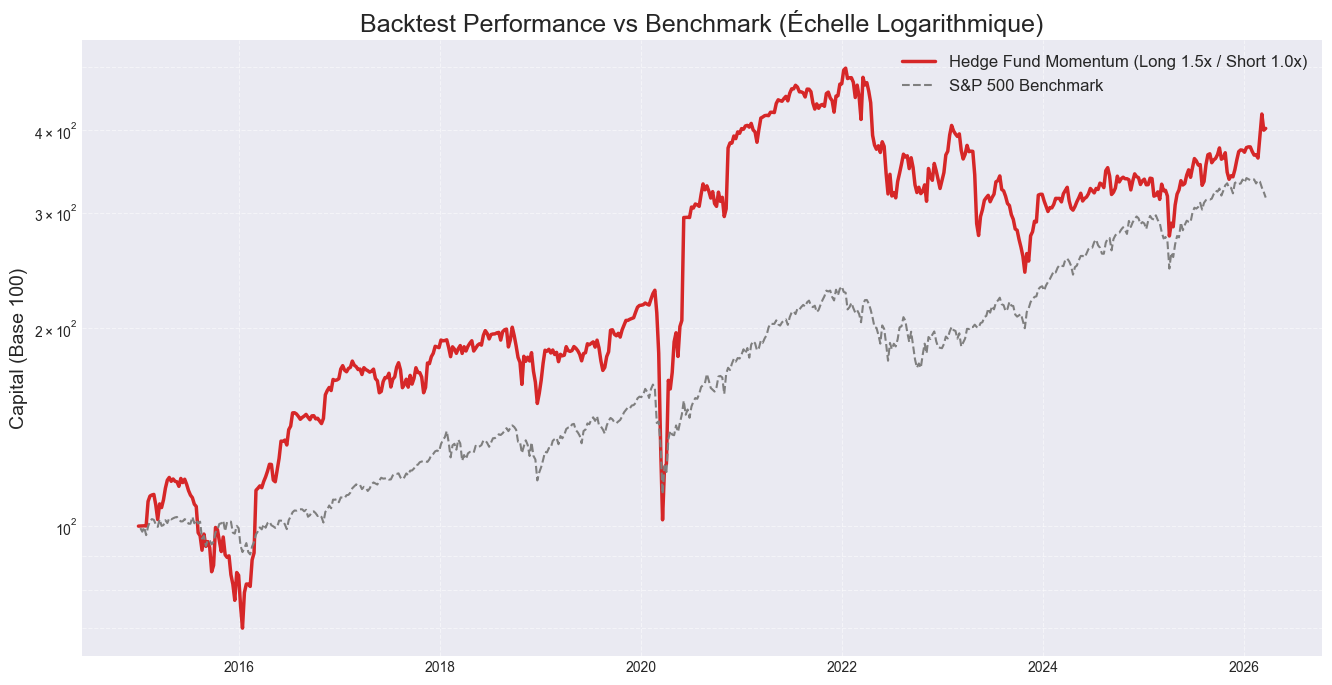

💰 Turnover moyen hebdomadaire : 27.00%
📈 Exposition brute moyenne (Gross Exposure) : 81.83%
📊 CAGR Net: 13.23% | Sharpe Net: 0.47 | Max DD: -55.24%


In [ ]:
import matplotlib.pyplot as plt

TRANSACTION_FEE = 0.001       
CASH_YIELD_ANNUAL = 0.02      
MARGIN_RATE_ANNUAL = 0.06     

CASH_YIELD_WEEKLY = CASH_YIELD_ANNUAL / 52
MARGIN_RATE_WEEKLY = MARGIN_RATE_ANNUAL / 52

print("📊 Calcul des rendements nets (Long/Short)...")

etf_prices = etfs.pivot(index='date', columns='Ticker', values='Close')
stock_prices = stocks.pivot(index='date', columns='Ticker', values='adjClose') if not stocks.empty else pd.DataFrame()
all_prices = pd.concat([etf_prices, stock_prices], axis=1).ffill()
weekly_asset_returns = all_prices.pct_change()

allocations_shifted = allocations.shift(1).fillna(0)
common_dates = allocations_shifted.index.intersection(weekly_asset_returns.index)

allocations_aligned = allocations_shifted.loc[common_dates]
returns_aligned = weekly_asset_returns.loc[common_dates, allocations_aligned.columns].fillna(0)

# --- 1. CALCUL DES EXPOSITIONS (Avec Valeur Absolue pour les Shorts) ---
gross_exposure = allocations_aligned.abs().sum(axis=1)

cash_weight = (1.0 - gross_exposure).clip(lower=0)
borrowed_weight = (gross_exposure - 1.0).clip(lower=0)

# --- 2. RENDEMENTS ET COÛTS ---
# Si allocation = -0.1 et return = -5%, le produit fait +0.005 (On gagne !)
asset_return = (allocations_aligned * returns_aligned).sum(axis=1) 
cash_return = cash_weight * CASH_YIELD_WEEKLY
margin_cost = borrowed_weight * MARGIN_RATE_WEEKLY

turnover = allocations.loc[common_dates].diff().abs().sum(axis=1).fillna(0)
transaction_costs = turnover * TRANSACTION_FEE

# --- 3. RENDEMENT NET FINAL ---
portfolio_return_weekly_net = asset_return + cash_return - margin_cost - transaction_costs

# --- COURBES DE CAPITAL ---
equity_curve = (1 + portfolio_return_weekly_net).cumprod() * 100
sp500_returns = sp500['Close'].pct_change().loc[common_dates]
sp500_equity = (1 + sp500_returns).cumprod() * 100

years = (equity_curve.index[-1] - equity_curve.index[0]).days / 365.25
cagr = ((equity_curve.iloc[-1] / 100) ** (1 / max(1e-5, years))) - 1

excess_return_weekly = portfolio_return_weekly_net.mean() - CASH_YIELD_WEEKLY
sharpe = (excess_return_weekly / portfolio_return_weekly_net.std()) * np.sqrt(52) if portfolio_return_weekly_net.std() != 0 else 0
max_dd = (equity_curve / equity_curve.cummax() - 1).min()

plt.figure(figsize=(16, 8))
plt.plot(equity_curve.index, equity_curve.values, label='Hedge Fund Momentum (Long 1.5x / Short 1.0x)', color='#d62728', linewidth=2.5)
plt.plot(sp500_equity.index, sp500_equity.values, label='S&P 500 Benchmark', color='#7f7f7f', linestyle='--', linewidth=1.5)
plt.title('Backtest Performance vs Benchmark (Échelle Logarithmique)', fontsize=18)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.ylabel('Capital (Base 100)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

print(f"💰 Turnover moyen hebdomadaire : {turnover.mean()*100:.2f}%")
print(f"📈 Exposition brute moyenne (Gross Exposure) : {gross_exposure.mean()*100:.2f}%")
print(f"📊 CAGR Net: {cagr*100:.2f}% | Sharpe Net: {sharpe:.2f} | Max DD: {max_dd*100:.2f}%")